In [1]:
import torch

In [4]:
torch.__version__

'2.12.0+cpu'

In [6]:
# 스칼라(0차원)
t0 = torch.tensor(3.14)
# 벡터(1차원)
t1 = torch.tensor([1.0, 2.0, 3.0])
# 행렬(2차원)
t2 = torch.zeros(3,4)
# 이미지(3차원)
t3 = torch.zeros(3, 28, 28)
# 배치(4차원)
t4 = torch.zeros(64, 3, 28, 28)

In [9]:
# tensor 데이터 살펴보기 
print(type(t0))
print(t0.dtype)
print(t0.shape)

<class 'torch.Tensor'>
torch.float32
torch.Size([])


In [10]:
# 내 환경 확인 (cuda : GPU 라이브러리) 
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cpu'

In [11]:
A = torch.rand(3, 4)
B = torch.rand(4, 5)
A.shape, B.shape

(torch.Size([3, 4]), torch.Size([4, 5]))

In [12]:
# 행렬곱
C = A @ B
print(C)
# or
torch.matmul(A, B)


tensor([[1.2530, 1.3428, 1.1961, 1.7669, 1.1680],
        [1.1794, 0.8533, 1.0998, 1.6366, 0.8565],
        [1.3323, 1.2722, 1.0494, 1.4946, 1.0865]])


tensor([[1.2530, 1.3428, 1.1961, 1.7669, 1.1680],
        [1.1794, 0.8533, 1.0998, 1.6366, 0.8565],
        [1.3323, 1.2722, 1.0494, 1.4946, 1.0865]])

In [20]:
x = torch.rand(2, 3, 4)
print(x)
# 차원 변경 (원소 개수 동일한 조합으로 변경 가능)
y = x.view(2, 12)  # x.reshape(2,12)
print(y)

tensor([[[0.5685, 0.1161, 0.8247, 0.7350],
         [0.7061, 0.2436, 0.3563, 0.7961],
         [0.2289, 0.3100, 0.3669, 0.2335]],

        [[0.9180, 0.4933, 0.6797, 0.9190],
         [0.3497, 0.6127, 0.3377, 0.3347],
         [0.3057, 0.7925, 0.8108, 0.5470]]])
tensor([[0.5685, 0.1161, 0.8247, 0.7350, 0.7061, 0.2436, 0.3563, 0.7961, 0.2289,
         0.3100, 0.3669, 0.2335],
        [0.9180, 0.4933, 0.6797, 0.9190, 0.3497, 0.6127, 0.3377, 0.3347, 0.3057,
         0.7925, 0.8108, 0.5470]])


In [21]:
x = torch.arange(24).view(2,3,4) #range와 비슷
x 



tensor([[[ 0,  1,  2,  3],
         [ 4,  5,  6,  7],
         [ 8,  9, 10, 11]],

        [[12, 13, 14, 15],
         [16, 17, 18, 19],
         [20, 21, 22, 23]]])

In [23]:
x[...,0] # ... 모든 것 포함

tensor([[ 0,  4,  8],
        [12, 16, 20]])

In [26]:
x = torch.tensor(3.0, requires_grad=True)
y = x**2 + 2*x + 1
y.backward()
print(f'f(3) = {y.item()}')
print(f'f(3) = {x.grad.item()}')

f(3) = 16.0
f(3) = 8.0


### nn.Module

In [27]:
import torch, torch.nn as nn

class SimpleNet(nn.Module):
    def __init__(self): # 생성자 
        super().__init__() # 호출
        self.linear = nn.Linear(4,2)
    def forward(self, x):
        return self.linear(x)
                 

In [30]:
model = SimpleNet()
x = torch.rand(3, 4)
y = model(x)


### nn.Sequential

In [33]:
model = nn.Sequential(
    nn.Linear(4,8),
    nn.ReLU(),
    nn.Linear(8,2)
)
y = model(x)

In [36]:
for name, p in model.named_parameters():
    print(f'{name}:{tuple(p.shape)}')

0.weight:(8, 4)
0.bias:(8,)
2.weight:(2, 8)
2.bias:(2,)


In [37]:
for p in model.parameters():
    print(p.numel())

32
8
16
2


In [38]:
block1 = nn.Sequential(nn.Linear(100,64),nn.ReLU())
block2 = nn.Sequential(nn.Linear(64,32),nn.ReLU())
model = nn.Sequential(block1,block2, nn.Linear(32,10))
print(model)

Sequential(
  (0): Sequential(
    (0): Linear(in_features=100, out_features=64, bias=True)
    (1): ReLU()
  )
  (1): Sequential(
    (0): Linear(in_features=64, out_features=32, bias=True)
    (1): ReLU()
  )
  (2): Linear(in_features=32, out_features=10, bias=True)
)


In [44]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

In [46]:
transform = transforms.ToTensor()

train_data = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_data = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)


In [39]:
!uv add matplotlib

Resolved 75 packages in 241ms
 Downloaded fonttools
Prepared 1 package in 158ms
Installed 6 packages in 709ms
 + contourpy==1.3.3
 + cycler==0.12.1
 + fonttools==4.63.0
 + kiwisolver==1.5.0
 + matplotlib==3.10.9
 + pyparsing==3.3.2


In [42]:
import matplotlib.pyplot as plt
import numpy as np

In [47]:
image, label = train_data[0]
type(image), type(label)

(torch.Tensor, int)

In [52]:
# PIL -> Numpy 
image_np = np.array(image)
type(image_np), image_np.shape

C:\Users\UserK\AppData\Local\Temp\ipykernel_19640\2196682066.py:2: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  image_np = np.array(image)


(numpy.ndarray, (1, 28, 28))

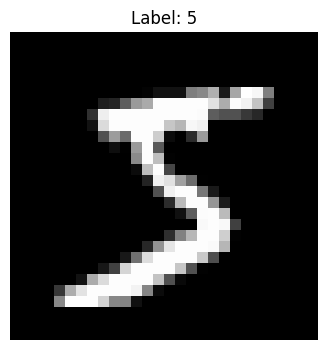

In [53]:
plt.figure(figsize=(4,4))
plt.imshow(image_np.squeeze(),cmap='gray')
plt.title(f'Label: {label}')
plt.axis('off')
plt.show()



In [57]:
trm = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.1307,), (0.3081,))])
train = datasets.MNIST(
    root = './data',
    train = True,
    download = True,
    transform = trm
)

In [58]:
image, label = train[0]
type(image)

torch.Tensor

In [59]:
image.shape

torch.Size([1, 28, 28])

In [60]:
loader = DataLoader(train, batch_size = 64, shuffle=True)



In [61]:
type(loader)

torch.utils.data.dataloader.DataLoader

In [62]:
batch_x, batch_y = next(iter(loader))
batch_x.shape, batch_y.shape

(torch.Size([64, 1, 28, 28]), torch.Size([64]))

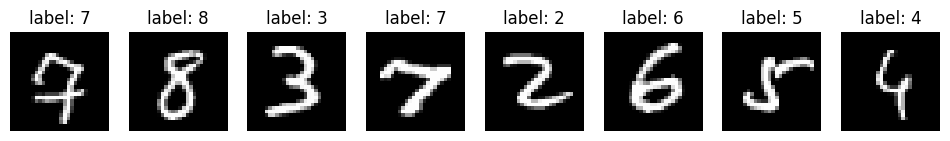

In [67]:
images, labels = next(iter(loader))

fig, axes = plt.subplots(1, 8, figsize=(12, 2))

for i, ax in enumerate(axes):
    ax.imshow(images[i].squeeze(), cmap='gray')
    ax.set_title(f'label: {int(labels[i])}')
    ax.axis('off')

plt.show()

